In [1]:
import os
try:
    path_initialized
except NameError:
    path_initialized = True
    os.chdir('..')

import numpy as np
from sympy.abc import x, y

from qldpc import codes
from qldpc.objects import Pauli
import networkx as nx
import matplotlib.pyplot as plt

import src.device as device
import src.plotting as plotter
from src.RotatedSurfaceCode import RotatedSurfaceCode
from src.HGPCode import HGPCode
from src.GBCode import GBCode
from src.QECCode import TestCode

In [2]:
l,m = 6,6
code_bb = GBCode(l, m, ([3], [1, 2]), ([1, 2], [3]))

buffer = 1
xmax,ymax = 0,0
data_coords = dict()
for i in code_bb.data_indices:
    x,y = code_bb.qubit_coords[i]
    data_coords[i] = (y+buffer, x+buffer)
    xmax = max(xmax, y)
    ymax = max(ymax, x)

anc_coords = dict()
for q in code_bb.X_ancilla_indices:
    i = q - len(code_bb.data_indices)
    anc_coords[q] = (i % m, i // m)
for q in code_bb.Z_ancilla_indices:
    i = q - len(code_bb.data_indices) - len(code_bb.X_ancilla_indices)
    anc_coords[q] = (i % m, i // m)

dev = device.UnitCellDevice(xmax+2*buffer+1, ymax+2*buffer+1, device.default_hwp)

sched_bb = dev.compile_QEC_schedule(
    code_bb,
    data_coords,
    [],
    rounds=1,
    use_highways=False,
    refocus_shuttle_noise=True,
    separate_X_Z=True
)

/home/jchadwick/projects/shuttle-ldpc/.venv/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [3]:
code_bb.qubit_coords

[(0, 0),
 (1, 0),
 (2, 0),
 (3, 0),
 (4, 0),
 (5, 0),
 (0, 1),
 (1, 1),
 (2, 1),
 (3, 1),
 (4, 1),
 (5, 1),
 (0, 2),
 (1, 2),
 (2, 2),
 (3, 2),
 (4, 2),
 (5, 2),
 (0, 3),
 (1, 3),
 (2, 3),
 (3, 3),
 (4, 3),
 (5, 3),
 (0, 4),
 (1, 4),
 (2, 4),
 (3, 4),
 (4, 4),
 (5, 4),
 (0, 5),
 (1, 5),
 (2, 5),
 (3, 5),
 (4, 5),
 (5, 5),
 (0, 6),
 (1, 6),
 (2, 6),
 (3, 6),
 (4, 6),
 (5, 6),
 (0, 7),
 (1, 7),
 (2, 7),
 (3, 7),
 (4, 7),
 (5, 7),
 (0, 8),
 (1, 8),
 (2, 8),
 (3, 8),
 (4, 8),
 (5, 8),
 (0, 9),
 (1, 9),
 (2, 9),
 (3, 9),
 (4, 9),
 (5, 9),
 (0, 10),
 (1, 10),
 (2, 10),
 (3, 10),
 (4, 10),
 (5, 10),
 (0, 11),
 (1, 11),
 (2, 11),
 (3, 11),
 (4, 11),
 (5, 11)]

In [4]:
len(code_bb.data_indices), len(code_bb.X_ancilla_indices), len(code_bb.Z_ancilla_indices)

(72, 36, 36)

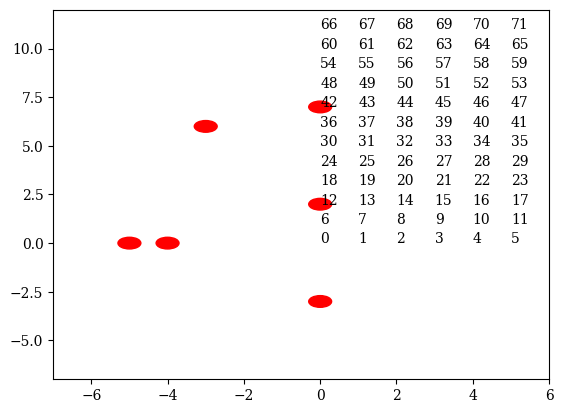

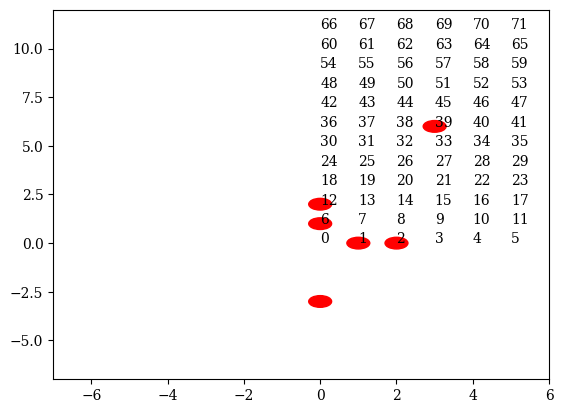

In [5]:
# TODO: define ancilla reference positions (for tiled optimization)

# 0 through 4: i+1 = i shifted over by +1X
# 5: i+1 = i shifted by +1X,+1Y
# 6 through 10: i+1 = i shifted over by +1X
# 11: i+1 = i shifted by +1X,+1Y

anc_idx = 29
for i,q in enumerate(code_bb.data_indices):
    plt.text(*code_bb.qubit_coords[i], q, zorder=2)
for q in code_bb.X_checks[anc_idx]:
    xa = code_bb.qubit_coords[q][0] - anc_coords[code_bb.X_ancilla_indices[anc_idx]][0]
    ya = code_bb.qubit_coords[q][1] - anc_coords[code_bb.X_ancilla_indices[anc_idx]][1]
    plt.gca().add_patch(plt.Circle((xa, ya), 0.3, color='r'))
plt.xlim(-m-1, ymax+1)
plt.ylim(-m-1, xmax+1)
plt.show()

anc_idx += 1
for i,q in enumerate(code_bb.data_indices):
    plt.text(*code_bb.qubit_coords[i], q, zorder=2)
for q in code_bb.X_checks[anc_idx]:
    xa = code_bb.qubit_coords[q][0] - anc_coords[code_bb.X_ancilla_indices[anc_idx]][0]
    ya = code_bb.qubit_coords[q][1] - anc_coords[code_bb.X_ancilla_indices[anc_idx]][1]
    plt.gca().add_patch(plt.Circle((xa, ya), 0.3, color='r'))
plt.xlim(-m-1, ymax+1)
plt.ylim(-m-1, xmax+1)
plt.show()

In [6]:
frames = sched_bb.get_frames(50)

Issue at t=18100
	Overlapping: [74, 124] at pos (0.6, 4.8)
	Overlapping: [74, 124] at pos (0.6, 4.8)
Issue at t=18150
	Overlapping: [74, 124] at pos (0.6, 4.8)
	Overlapping: [74, 124] at pos (0.6, 4.8)
Issue at t=18200
	Overlapping: [74, 124] at pos (0.6, 4.8)
	Overlapping: [74, 124] at pos (0.6, 4.8)
Issue at t=18250
	Overlapping: [74, 124] at pos (0.6, 4.8)
	Overlapping: [74, 124] at pos (0.6, 4.8)
Issue at t=18300
	Overlapping: [74, 124] at pos (0.6, 4.8)
	Overlapping: [74, 124] at pos (0.6, 4.8)
Issue at t=18350
	Overlapping: [74, 124] at pos (0.6, 4.8)
	Overlapping: [74, 124] at pos (0.6, 4.8)
Issue at t=18400
	Overlapping: [74, 124] at pos (0.6, 4.8)
	Overlapping: [74, 124] at pos (0.6, 4.8)
Issue at t=18450
	Overlapping: [74, 124] at pos (0.6, 4.8)
	Overlapping: [74, 124] at pos (0.6, 4.8)
Issue at t=18500
	Overlapping: [74, 124] at pos (0.6, 4.8)
	Overlapping: [74, 124] at pos (0.6, 4.8)
Issue at t=18550
	Overlapping: [74, 124] at pos (0.6, 4.8)
	Overlapping: [74, 124] at pos (

MovieWriter imagemagick unavailable; using Pillow instead.


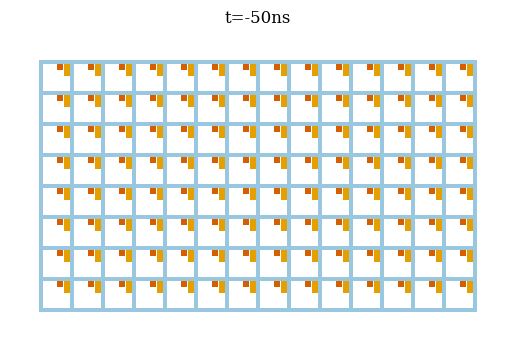

In [7]:
anim = plotter.animate_device(dev, code_bb, frames, 'anim_bb.gif', fps=10)

t=20950 to 21950 (dt=1000)


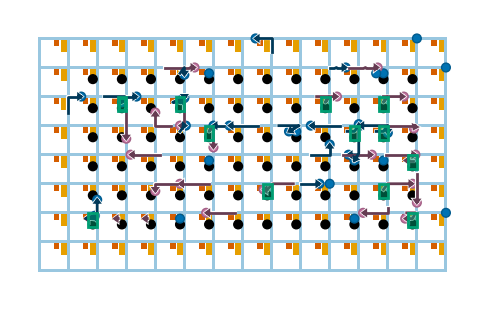

In [8]:
start = 420
ct = 21
ax = plotter.plot_transition(dev, code_bb, frames[start:start+ct])
print(ax.get_title())
ax.set_title('')
plt.savefig('notebooks/fig/03_snapshot.pdf', bbox_inches='tight')
plt.savefig('notebooks/fig/03_snapshot.svg', bbox_inches='tight')
plt.show()